In [1]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from torchvision import transforms, datasets

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name(device))
print(device)

Tesla T4
cuda:0


Ex.1

In [3]:
dataset = torch.load("dataset.pt")
type(dataset)

dict

In [4]:
keys = dataset.keys()
values = dataset.values()
X_train, y_train, X_val, y_val, X_test, y_test = values

In [5]:
print('training set')
print(X_train.data.shape)
print(y_train.data.shape)
print('validation set')
print(X_val.data.shape)
print(y_val.data.shape)
print('test set')
print(X_test.data.shape)
print(y_test.data.shape)

training set
torch.Size([4000, 276])
torch.Size([4000])
validation set
torch.Size([100, 276])
torch.Size([100])
test set
torch.Size([2000, 276])
torch.Size([2000])


Ex.2

tensor(-1655.6700)


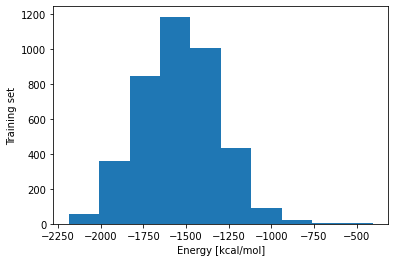

In [6]:
# y_train = np.array(dataset['y_train'])
plt.hist(y_train)
plt.xlabel("Energy [kcal/mol]")
plt.ylabel("Training set")
print(dataset['y_train'][0])

Text(0, 0.5, 'Training set')

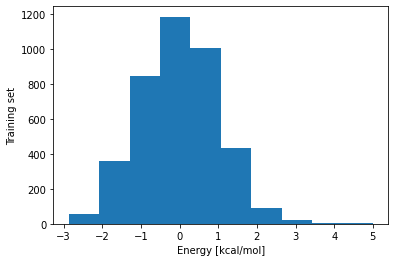

In [7]:
# keep track of the mean and the std

mean_train = torch.mean(y_train)
std_train = torch.std(y_train)
y_train = (y_train - mean_train) / std_train

plt.hist(y_train)
plt.xlabel("Energy [kcal/mol]")
plt.ylabel("Training set")

In [8]:
y_val = (y_val - mean_train) / std_train
y_test = (y_test - mean_train) / std_train


Ex.3

In [9]:
from torch.utils.data import TensorDataset, DataLoader

In [10]:
train = TensorDataset(X_train, y_train)
val = TensorDataset(X_val, y_val)
test = TensorDataset(X_test, y_test)

train_data_loader = DataLoader(train, batch_size=100, shuffle=True, num_workers=1)
val_data_loader = DataLoader(val, batch_size=100, shuffle=False, num_workers=1)
test_data_loader = DataLoader(test, batch_size=100, shuffle=False, num_workers=1)

Ex.4

In [11]:
import torch.nn as nn

In [12]:
class NeuralNetwork(nn.Module):
    
    def __init__(self, hidden_neurons):
        super().__init__()
        self.layers = nn.Sequential(
                      nn.Linear(276, hidden_neurons, bias=True),
                      nn.ReLU(),
                      nn.Linear(hidden_neurons, 1, bias=True)
                      )

    def forward(self, x):
        x = self.layers(x)
        return x.reshape((len(x),))


Ex.5

In [13]:
import torch.optim as optim
import pandas as pd

In [14]:
def train_loop(train_data_loader, val_data_loader, model, epochs, learning_rate, optimizer = 'SGD', loss = 'MSE'):

  
  if loss == 'MSE':
    l = torch.nn.MSELoss()
  if optimizer == 'SGD':
    o = optim.Adam(model.parameters(), lr=learning_rate)

  # extract the size of the training set
  size = len(train_data_loader.dataset)

  # initialize an empty dictionary
  res = {'epoch': [], 'train_loss': [], 'val_loss': []}

  for e in range(epochs):
    print(f"Epoch {e+1}\n-------------------------------")

    train_loss = 0
  
    for batch, (X, y) in enumerate(train_data_loader): 
        
      X = X.to(device)
      y = y.to(device)

      o.zero_grad()  # setting gradient to zeros       
      pred = model(X)  # get predictions through forward pass
      loss = l(pred, y)  # compute the loss
      loss.backward()  # backward propagation        
      o.step()  # update the gradient to new gradients

      train_loss += loss.item()

      # check how the training is evolving accross the batches
      if batch % 40 == 39:
        print(f"Processing batch n. {batch+1} ----> running loss: {train_loss/(batch + 1):>7f}")

    train_loss = train_loss/(batch + 1)
    
    # initialize the validation loss
    val_loss = 0

    # create the container to avoid gradient computation
    with torch.no_grad():
      # loop over all test input-output pairs
      for X, y in val_data_loader: 

        X = X.to(device)
        y = y.to(device)
      
        pred = model(X)  # get predictions through forward pass
        loss = l(pred, y)  # compute the loss

        val_loss += loss.item()

    val_loss = val_loss/len(val_data_loader)

    # populate the dictionary of results
    res['epoch'].append(e)
    res['train_loss'].append(train_loss)
    res['val_loss'].append(val_loss)

  print("Done!")

  res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
  res.to_csv(f"./metrics_lr={learning_rate}.csv", mode = 'w', index = False) # store the results into a *.csv file
  
  return

In [15]:
# define the hyper-parameters of the network training
epochs = 1000
optimizer = 'SGD'
loss = 'MSE'
learning_rates = np.logspace(-5, -2, 4)
p = 1000   # number of hidden neurons

for lr in learning_rates:
    print(f"learning rate = {lr}")
    model = NeuralNetwork(p)
    model.to(device)
    train_loop(train_data_loader, val_data_loader, model, epochs, lr, optimizer, loss)

Output streaming troncato alle ultime 5000 righe.
-------------------------------
Processing batch n. 40 ----> running loss: 0.001082
Epoch 336
-------------------------------
Processing batch n. 40 ----> running loss: 0.000312
Epoch 337
-------------------------------
Processing batch n. 40 ----> running loss: 0.000418
Epoch 338
-------------------------------
Processing batch n. 40 ----> running loss: 0.000550
Epoch 339
-------------------------------
Processing batch n. 40 ----> running loss: 0.000377
Epoch 340
-------------------------------
Processing batch n. 40 ----> running loss: 0.000242
Epoch 341
-------------------------------
Processing batch n. 40 ----> running loss: 0.000205
Epoch 342
-------------------------------
Processing batch n. 40 ----> running loss: 0.000331
Epoch 343
-------------------------------
Processing batch n. 40 ----> running loss: 0.000415
Epoch 344
-------------------------------
Processing batch n. 40 ----> running loss: 0.000868
Epoch 345
----------

In [16]:
import matplotlib.pyplot as plt
import matplotlib

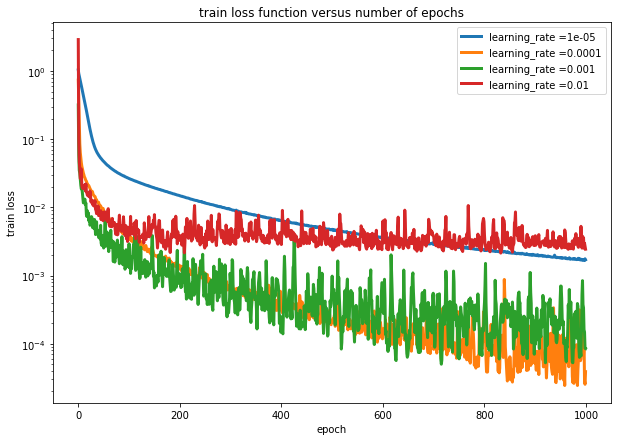

In [17]:
# plot the train loss as a function of the number of epochs for different learning rates

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object

for i in learning_rates:
    res = pd.read_csv(f"./metrics_lr={i}.csv") # read the content of the *.csv file

    res.plot(x='epoch',
             y='train_loss',
             label = f'learning_rate ={i}',
             lw = 3, # linewidth
             ax=ax) # plot the results with matplotlib through pandas

    ax.set_title("train loss function versus number of epochs") # set the plot title
    ax.set_ylabel("train loss") # set the name of the y axis
    ax.set_xlabel("epoch") # set the name of the x axis
    ax.set_xscale('linear')
    ax.set_yscale('log')

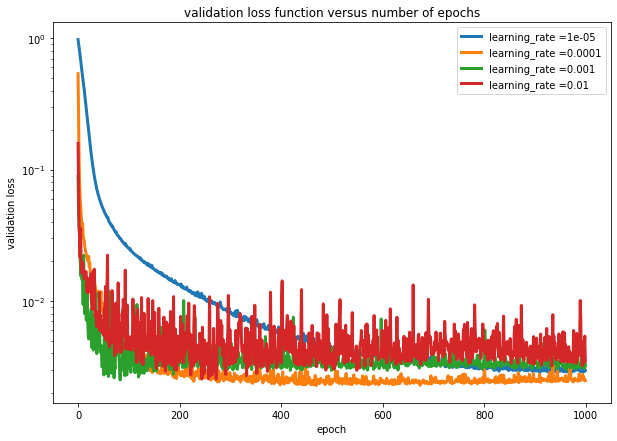

In [18]:
# plot the validation loss as a function of the number of epochs for different learning rates
learning_rates = np.logspace(-5, -2, 4)

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object

for i in learning_rates:
    res = pd.read_csv(f"./metrics_lr={i}.csv") # read the content of the *.csv file

    res.plot(x='epoch',
             y='val_loss',
             label = f'learning_rate ={i}',
             lw = 3, # linewidth
             ax=ax) # plot the results with matplotlib through pandas

    ax.set_title("validation loss function versus number of epochs") # set the plot title
    ax.set_ylabel("validation loss") # set the name of the y axis
    ax.set_xlabel("epoch") # set the name of the x axis
    ax.set_xscale('linear')
    ax.set_yscale('log')


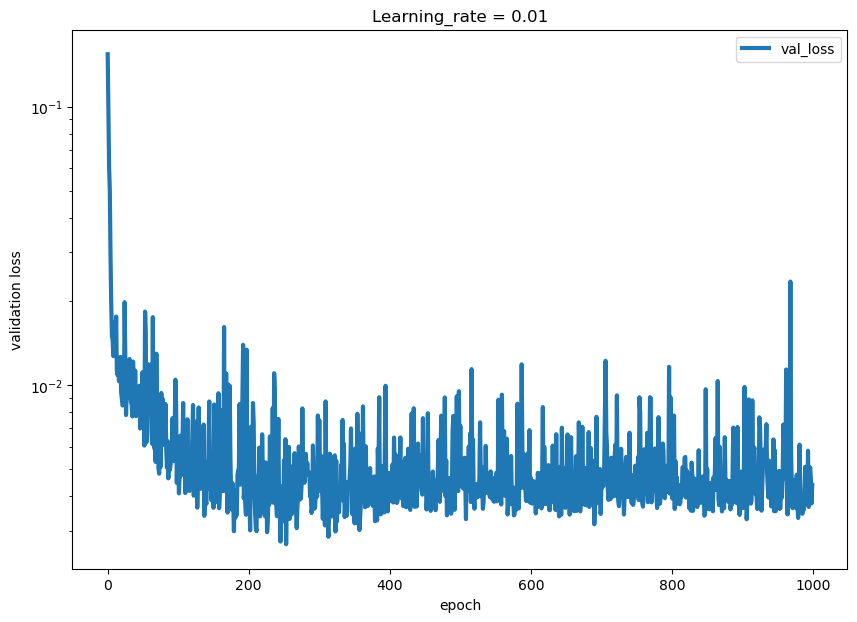

In [ ]:
# just for single plots
learning_rates = np.logspace(-5, -2, 4)

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object

res = pd.read_csv("./metrics_lr=0.01.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='val_loss',
         lw = 3, 
         ax=ax)

ax.set_title("Learning_rate = 0.01") # set the plot title
ax.set_ylabel("validation loss") # set the name of the y axis
ax.set_xlabel("epoch") # set the name of the x axis
ax.set_xscale('linear')
ax.set_yscale('log')
    


Ex.6

In [19]:
from sklearn.metrics import mean_squared_error

In [26]:
def test_loop(test_data_loader, model, loss = 'MSE'):
  
  if loss == 'MSE':
    l = torch.nn.MSELoss()

  test_loss = 0.

  with torch.no_grad():

    for X_test, y_test in test_data_loader:
      
      X_test = X_test.to(device)
      y_test = y_test.to(device)
      y_pred = model(X_test)
      loss = l(y_pred, y_test)
      
      # compute the metrics of interest
      X_test = X_test.to('cpu')
      y_test = y_test.to('cpu')
      y_pred = y_pred.to('cpu')

      test_loss += loss.item()

  test_loss = test_loss/len(test_data_loader)
  print("test loss =  ", test_loss)

  return y_test, y_pred

Epoch 1
-------------------------------
Processing batch n. 40 ----> running loss: 0.272860
Epoch 2
-------------------------------
Processing batch n. 40 ----> running loss: 0.052696
Epoch 3
-------------------------------
Processing batch n. 40 ----> running loss: 0.035862
Epoch 4
-------------------------------
Processing batch n. 40 ----> running loss: 0.028555
Epoch 5
-------------------------------
Processing batch n. 40 ----> running loss: 0.027647
Epoch 6
-------------------------------
Processing batch n. 40 ----> running loss: 0.021431
Epoch 7
-------------------------------
Processing batch n. 40 ----> running loss: 0.018137
Epoch 8
-------------------------------
Processing batch n. 40 ----> running loss: 0.015745
Epoch 9
-------------------------------
Processing batch n. 40 ----> running loss: 0.017411
Epoch 10
-------------------------------
Processing batch n. 40 ----> running loss: 0.015845
Epoch 11
-------------------------------
Processing batch n. 40 ----> running l

TypeError: ignored

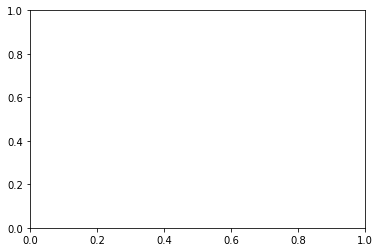

In [22]:
# train with optimal learning rate
lr_optimal = 1e-4
d = X_train.data.shape[1]
p= 1000
epochs = 1000

model = NeuralNetwork(p)
model.to(device)

train_loop(train_data_loader, test_data_loader, model, epochs, lr_optimal, optimizer, loss)
y, pred = test_loop(test_data_loader, model, loss='MSE')

y = std_train * y + mean_train
pred = std_train * pred + mean_train

plt.scatter(y, pred)
plt.title("Test predictors as function of test labels")
plt.xlabel("y_test")
plt.ylabel("y_test predicted")

rmse_test = np.sqrt(mean_squared_error(y, pred))

test loss =   0.008404550608247519
18.961336


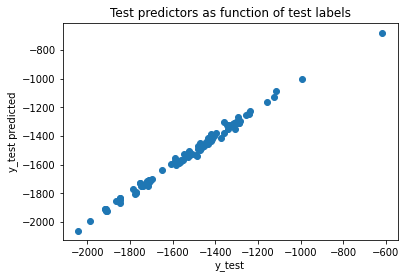

In [33]:
y, pred = test_loop(test_data_loader, model, loss='MSE')

y = std_train * y + mean_train
pred = std_train * pred + mean_train

plt.scatter(y, pred)
plt.title("Test predictors as function of test labels")
plt.xlabel("y_test")
plt.ylabel("y_test predicted")

rmse_test = np.sqrt(mean_squared_error(y, pred))
print(rmse_test)

Text(0.5, 0, 'epoch')

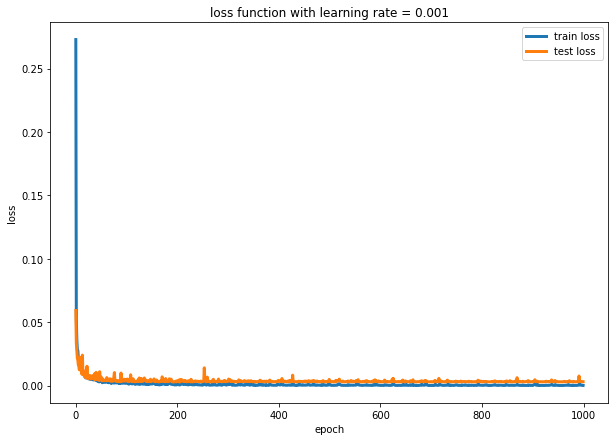

In [28]:
# plot the train and test loss function over the epochs

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
    
res = pd.read_csv(f"./metrics_lr={lr_optimal}.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='train_loss',
         label ='train loss',
         lw = 3,
         ax=ax)

res.plot(x='epoch',
         y='val_loss',
         label ='test loss',
         lw = 3,
         ax=ax)

ax.set_title(f"loss function with learning rate = {lr_optimal}") # set the plot title
ax.set_ylabel("loss") # set the name of the y axis
ax.set_xlabel("epoch") # set the name of the x axis



Ex.7

In [29]:
def train_loop(train_data_loader, test_data_loader, model, epochs, learning_rate, optimizer = 'SGD', loss = 'MSE'):

  
  if loss == 'MSE':
    l = torch.nn.MSELoss()
  if optimizer == 'SGD':
    o = optim.Adam(model.parameters(), lr=learning_rate)

  # extract the size of the training set
  size = len(train_data_loader.dataset)

  # initialize an empty dictionary
  res = {'epoch': [], 'train_loss': [], 'test_loss': []}

  for e in range(epochs):
    print(f"Epoch {e+1}\n-------------------------------")

    train_loss = 0
  
    for batch, (X, y) in enumerate(train_data_loader): 
        
      X = X.to(device)
      y = y.to(device)

      o.zero_grad()  # setting gradient to zeros       
      pred = model(X)  # get predictions through forward pass
      loss = l(pred, y)  # compute the loss
      loss.backward()  # backward propagation        
      o.step()  # update the gradient to new gradients

      train_loss += loss.item()

      # check how the training is evolving accross the batches
      print_every = size / 100
      if batch % print_every == print_every-1:
        print(f"Processing batch n. {batch+1} ----> running loss: {train_loss/(batch + 1):>7f}")

    
    train_loss = train_loss/(batch + 1)

    
    # initialize the validation loss
    test_loss = 0

    # create the container to avoid gradient computation
    with torch.no_grad():
      # loop over all test input-output pairs
      for X, y in test_data_loader: 

        X = X.to(device)
        y = y.to(device)
      
        pred = model(X)  # get predictions through forward pass
        loss = l(pred, y)  # compute the loss
      
        test_loss += loss.item()

    test_loss = test_loss/len(test_data_loader)

    # populate the dictionary of results
    res['epoch'].append(e)
    res['train_loss'].append(train_loss)
    res['test_loss'].append(test_loss)

  print("Done!")

  res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
  res.to_csv(f"./metrics_n={size}.csv", mode = 'w', index = False) # store the results into a *.csv file
  
  return

Output streaming troncato alle ultime 5000 righe.
Processing batch n. 5 ----> running loss: 0.003132
Epoch 336
-------------------------------
Processing batch n. 5 ----> running loss: 0.003398
Epoch 337
-------------------------------
Processing batch n. 5 ----> running loss: 0.003173
Epoch 338
-------------------------------
Processing batch n. 5 ----> running loss: 0.003137
Epoch 339
-------------------------------
Processing batch n. 5 ----> running loss: 0.002977
Epoch 340
-------------------------------
Processing batch n. 5 ----> running loss: 0.002969
Epoch 341
-------------------------------
Processing batch n. 5 ----> running loss: 0.002964
Epoch 342
-------------------------------
Processing batch n. 5 ----> running loss: 0.002924
Epoch 343
-------------------------------
Processing batch n. 5 ----> running loss: 0.002903
Epoch 344
-------------------------------
Processing batch n. 5 ----> running loss: 0.002933
Epoch 345
-------------------------------
Processing batch n. 

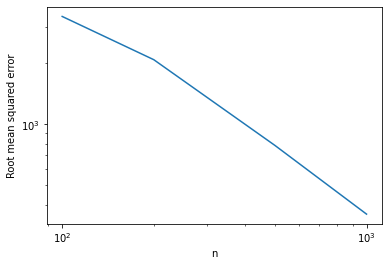

In [31]:
#retrain varing the number of samples

lr_optimal = 1e-4
n_samples = [100, 200, 500, 1000]
test_error = []

optimizer = 'SGD'
loss = 'MSE'
d = X_train.data.shape[1]
p= 1000
epochs = 1000
output_size = 1


for n in n_samples:
    
    model = NeuralNetwork(p)
    model.to(device)

    X_train_cut = X_train[:n][:]
    y_train_cut = y_train[:n]

    train_cut = TensorDataset(X_train_cut, y_train_cut)
    train_cut_loader = DataLoader(train_cut, batch_size=100, shuffle=True, num_workers=1)
    
    train_loop(train_cut_loader, test_data_loader, model, epochs, lr_optimal, optimizer, loss)

    y, pred = test_loop(test_data_loader, model, loss='MSE')

    y = std_train * y + mean_train
    pred = std_train * pred + mean_train

    test_error.append(mean_squared_error(y, pred))

# plot test error vs number of training points

plt.plot(n_samples, test_error)
plt.xlabel('n')
plt.ylabel('Root mean squared error')
plt.yscale('log')
plt.xscale('log')
plt.show()


/usr/local/lib/python3.8/dist-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


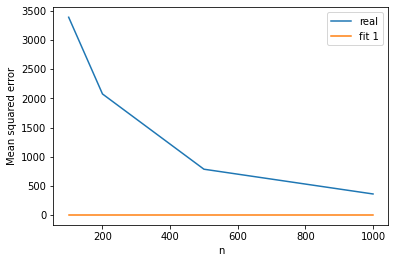

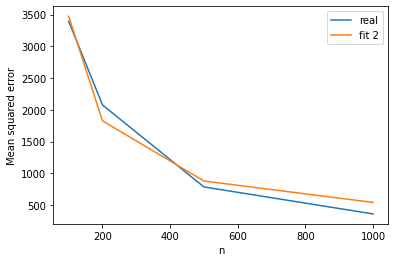

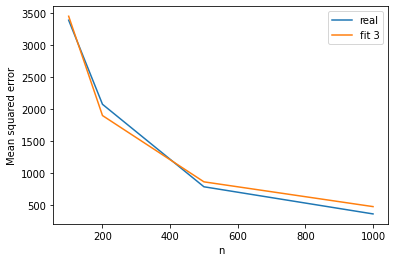

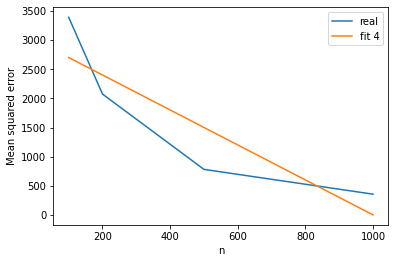

In [32]:
# fitting the learning curve 

from scipy.optimize import curve_fit

test_error = np.array(test_error)
n_samples= np.array(n_samples)

def f1(x, A, beta):
    return A * np.exp(-beta*x)

def f2(x, A, beta):
 return (A)*(np.log10(x))**(-beta)

def f3(x, A, beta):
 return -A * x**(beta)

def f4(x, A, beta):
 return -(beta*x) + A

parameters1, pcov1 = curve_fit(f1, n_samples, test_error)
A1, beta1 = parameters1
y_fit1 = f1(n_samples, A1, beta1)

plt.plot(n_samples, test_error, label = 'real')
plt.plot(n_samples , y_fit1, label = 'fit 1')
plt.xlabel('n')
plt.ylabel('Mean squared error')
plt.legend()
plt.show()

popt2, pcov2 = curve_fit(f2, n_samples, test_error)
A2, beta2 = popt2
y_fit2 = f2(n_samples, A2, beta2)

plt.plot(n_samples, test_error, label = 'real')
plt.plot(n_samples, y_fit2, label = 'fit 2')
plt.xlabel('n')
plt.ylabel('Mean squared error')
plt.legend()
plt.show()

popt3, pcov3 = curve_fit(f3, n_samples, test_error)
A3, beta3 = popt3
y_fit3 = f3(n_samples, A3, beta3)

plt.plot(n_samples, test_error, label = 'real')
plt.plot(n_samples , y_fit3, label = 'fit 3')
plt.xlabel('n')
plt.ylabel('Mean squared error')
plt.legend()
plt.show()

popt4, pcov4 = curve_fit(f4, n_samples, test_error)
A4, beta4 = popt4
y_fit4 = f4(n_samples, A4, beta4)

plt.plot(n_samples, test_error, label = 'real')
plt.plot(n_samples , y_fit4, label = 'fit 4')
plt.xlabel('n')
plt.ylabel('Mean squared error')
plt.legend()
plt.show()

In [34]:
# get the prediction 

mse_pred = f3(4000, A2, beta2)
rmse_pred = np.sqrt(mse_pred)
print(f"The root mean squared error for 4000 data points is {rmse_pred}")

The root mean squared error for 4000 data points is nan


<ipython-input-34-7e35a0d991a0>:4: RuntimeWarning: invalid value encountered in sqrt
  rmse_pred = np.sqrt(mse_pred)
